# Pricing Optimization Strategy using Demand Elasticity and Revenue Simulation

## Objective
To create a synthetic dataset that simulates real-world retail sales behaviour, including pricing variations, demand response, and customer segmentation.

## Why Synthetic Data?
Real-world datasets often lack controlled variations in pricing and demand relationships. Therefore, a synthetic dataset is generated using business logic to model:

- Price elasticity (demand response to price changes)
- Customer segment behaviour (Budget, Regular, Premium)
- Product category behaviour (Essential, General, Luxury)
- Realistic randomness and noise

## Dataset Overview
The dataset simulates:
- Daily sales data over a defined time period
- Multiple products across different categories
- Customer segments with varying price sensitivity
- Pricing fluctuations and their impact on demand

## Tools Used
- Python
- Pandas
- NumPy

---

In [15]:
import pandas as pd
import numpy as np

np.random.seed(42)

## Business Logic Definition

 -This section defines the core assumptions used to simulate realistic business behaviour in the dataset.

### Product Categories
- Essential: Low price sensitivity (inelastic demand)
- General: Moderate price sensitivity
- Luxury: High price sensitivity (elastic demand)

### Customer Segments
- Budget: Highly sensitive to price changes
- Regular: Moderately sensitive
- Premium: Less sensitive to price changes

### Regions
- East
- West

These factors influence how demand responds to pricing changes in the dataset.

In [18]:
# Product categories with elasticity behavior
categories = {
    "Essential": 0.5,
    "General": 1.0,
    "Luxury": 1.5
}

# Customer segments
segments = {
    "Budget": 1.3,
    "Regular": 1.0,
    "Premium": 0.7
}

# Regions
regions = ["East", "West"]

## Time Frame and Product Definition

This section defines the time range and number of products used in the dataset.

- The dataset simulates daily sales data for one year
- A total of 30 products are included
- This results in approximately 10,000+ records for analysis

In [21]:
dates = pd.date_range(start="2022-01-01", periods=365)
products = range(1, 31)

## Data Generation Logic

This section generates the dataset by simulating real-world sales transactions.

### Key Logic Applied:
- Each product is assigned a category and a customer segment
- Price variations are introduced to simulate market fluctuations
- Demand is adjusted based on price elasticity
- Random noise is added to reflect real-world uncertainty
- Additional attributes, such as region and promotion flags, are included

This structured approach ensures that the dataset reflects realistic pricing and demand relationships.

In [85]:
data = []

for date in dates:
    for product_id in products:
        
        # Assign category, segment, and region
        category = np.random.choice(list(categories.keys()))
        segment = np.random.choice(list(segments.keys()))
        region = np.random.choice(regions)
        
        # Base price and variation
        base_price = np.random.uniform(10, 100)
        price_change = np.random.uniform(-0.4, 0.4)
        actual_price = base_price * (1 + price_change)
        
        # Elasticity calculation
        elasticity = categories[category] * segments[segment]
        
        # Base demand based on category
        if category == "Essential":
            base_demand = np.random.randint(120, 200)
        elif category == "General":
            base_demand = np.random.randint(80, 160)
        else:  # Luxury
            base_demand = np.random.randint(40, 120)
        
        # Adjusted quantity
        quantity = base_demand * (1 - elasticity * price_change)
        
        # Add randomness (FIXED)
        quantity = max(1, int(quantity + np.random.normal(0, 2)))
        
        # Cost calculation
        cost = base_price * np.random.uniform(0.5, 0.8)
        
        # Promotion flag
        promotion = np.random.choice([0, 1], p=[0.7, 0.3])
        
        # Append row
        data.append([
            date, product_id, category, base_price,
            actual_price, quantity, cost,
            segment, region, promotion
        ])

## DataFrame Creation

This section converts the generated data into a structured DataFrame.

The DataFrame organizes all simulated records into tabular format, making it suitable for analysis and visualization.

In [87]:
df = pd.DataFrame(data, columns=[
    "Date", "Product_ID", "Category", "Base_Price",
    "Actual_Price", "Quantity_Sold", "Cost",
    "Customer_Segment", "Region", "Promotion_Flag"
])

## Feature Engineering

This section derives additional metrics required for analysis.

Revenue is calculated as:
Revenue = Actual Price × Quantity Sold

In [89]:
df["Revenue"] = df["Actual_Price"] * df["Quantity_Sold"]

## Data Preview


In [91]:
df.head()

,Date,Product_ID,Category,Base_Price,Actual_Price,Quantity_Sold,Cost,Customer_Segment,Region,Promotion_Flag,Revenue
0,2022-01-01,1,General,39.599932,29.205655,121,21.351344,Regular,West,1,3533.884209
1,2022-01-01,2,Essential,43.754471,43.549405,192,22.104415,Budget,East,0,8361.485682
2,2022-01-01,3,Essential,12.199919,8.854462,159,9.571658,Budget,East,1,1407.859443
3,2022-01-01,4,Luxury,81.317615,112.286329,49,62.696631,Regular,West,0,5502.030106
4,2022-01-01,5,Essential,33.550516,42.749575,148,19.356738,Regular,East,0,6326.937083


## Check Dataset Size

In [93]:
df.shape 

(10950, 11)

## Saving the Dataset



In [95]:
df.to_csv("../data/pricing_dataset.csv",index=False)

## Dataset Validation

This section validates whether the generated dataset follows expected business logic.

Key validations include:
- Relationship between price and demand
- Category-level behavior
- Data consistency and distribution

## 1. Check Price vs Demand Relationship

In [97]:
df[["Actual_Price", "Quantity_Sold"]].corr()

,Actual_Price,Quantity_Sold
Actual_Price,1.000000,-0.218159
Quantity_Sold,-0.218159,1.000000


## 2. Category Behavior Check

In [99]:
df.groupby("Category")[["Actual_Price", "Quantity_Sold"]].mean()

,Actual_Price,Quantity_Sold
Category,,
Essential,55.084089,159.300664
General,55.694258,119.358516
Luxury,55.539478,77.757977


## 3.Customer Segment Behavior

In [102]:
df.groupby("Customer_Segment")[["Actual_Price", "Quantity_Sold"]].mean()

,Actual_Price,Quantity_Sold
Customer_Segment,,
Budget,55.954439,117.222494
Premium,55.586742,118.200216
Regular,54.760407,120.079485


## 4.Visual Check

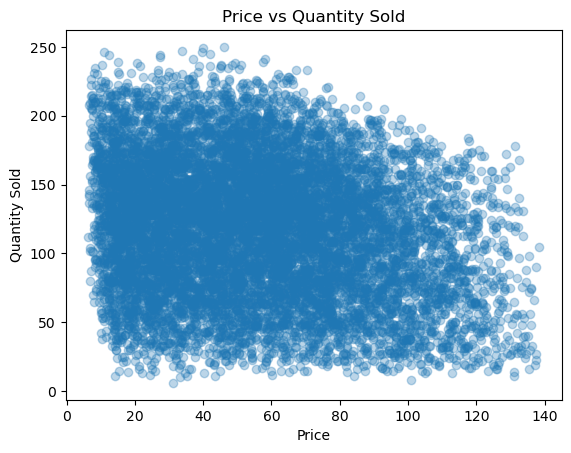

In [108]:
import matplotlib.pyplot as plt

plt.scatter(df["Actual_Price"], df["Quantity_Sold"], alpha=0.3)
plt.title("Price vs Quantity Sold")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.show()

## Price Elasticity of Demand Calculation

This section calculates the price elasticity of demand for each product.

Price elasticity measures how sensitive demand is to changes in price.

Elasticity Formula:
Elasticity = % Change in Quantity / % Change in Price

This helps identify:
- Elastic products (high sensitivity)
- Inelastic products (low sensitivity)

## Sort Data

In [112]:
df = df.sort_values(by=["Product_ID", "Date"])

## Calculate % Change

In [115]:
df["Price_Change_%"] = df.groupby("Product_ID")["Actual_Price"].pct_change()
df["Quantity_Change_%"] = df.groupby("Product_ID")["Quantity_Sold"].pct_change()

## Calculate Elasticity

In [118]:
df["Elasticity"] = df["Quantity_Change_%"] / df["Price_Change_%"]

## Clean Data

In [121]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Elasticity"])

## Check Results

In [124]:
df[["Product_ID", "Actual_Price", "Quantity_Sold", "Elasticity"]].head()

,Product_ID,Actual_Price,Quantity_Sold,Elasticity
30,1,73.514542,77,-0.239686
60,1,58.335495,103,-1.635352
90,1,53.461181,102,0.116194
120,1,22.413538,208,-1.789434
150,1,88.176584,126,-0.134363


## Product-Level Elasticity

In [127]:
product_elasticity = df.groupby("Product_ID")["Elasticity"].mean()
product_elasticity

Product_ID
1     -0.233028
2     -5.078374
3     -1.454214
4     -0.028072
5     -2.529392
6     -2.024211
7     -1.628235
8      2.508098
9     -0.564976
10    -0.196116
11    -0.731659
12     0.168623
13     6.227532
14    -0.219297
15    -0.021636
16     0.075022
17    -5.475762
18     1.835029
19     1.254670
20     3.836330
21     7.672142
22    -0.628711
23    -2.147518
24    -0.747501
25    -0.785425
26    -0.473210
27    -3.581014
28     1.679431
29    39.109573
30    -2.908627
Name: Elasticity, dtype: float64

## Classify Products

In [130]:
def classify(e):
    if abs(e) > 1:
        return "Elastic"
    else:
        return "Inelastic"

product_elasticity = product_elasticity.reset_index()
product_elasticity["Type"] = product_elasticity["Elasticity"].apply(classify)

product_elasticity.head()

,Product_ID,Elasticity,Type
0,1,-0.233028,Inelastic
1,2,-5.078374,Elastic
2,3,-1.454214,Elastic
3,4,-0.028072,Inelastic
4,5,-2.529392,Elastic


## Revenue Simulation

This section evaluates how changes in pricing impact revenue.

By simulating price increases, we estimate how demand reacts based on elasticity and calculate the resulting revenue.

This helps identify optimal pricing strategies.

## 1. Create Simulation Prices
- Example: increase price by 10%

In [136]:
df["Simulated_Price"] = df["Actual_Price"] * 1.10

## 2. Estimate New Quantity

In [139]:
df["Simulated_Quantity"] = df["Quantity_Sold"] * (
    1 + df["Elasticity"] * ((df["Simulated_Price"] - df["Actual_Price"]) / df["Actual_Price"])
)

In [143]:
df["Simulated_Quantity"] = df["Simulated_Quantity"].clip(lower=1)

## 3. Calculate New Revenue

In [146]:
df["Simulated_Revenue"] = df["Simulated_Price"] * df["Simulated_Quantity"]

## 4. Compare Revenue

In [149]:
df[["Revenue", "Simulated_Revenue"]].head()

,Revenue,Simulated_Revenue
30,5660.619747,6077.436625
60,6008.555962,5528.539828
90,5453.040450,6068.041412
120,4662.015822,4210.556923
150,11110.249599,12057.066109


## 5. Total Impact

In [153]:
original_revenue = df["Revenue"].sum()
simulated_revenue = df["Simulated_Revenue"].sum()

print("Original Revenue:", original_revenue)
print("Simulated Revenue:", simulated_revenue)

Original Revenue: 68333474.99855356
Simulated Revenue: 106857895.58748645


In [156]:
for change in [0.05, 0.10, 0.15]:
    temp_price = df["Actual_Price"] * (1 + change)
    temp_quantity = df["Quantity_Sold"] * (
        1 + df["Elasticity"] * ((temp_price - df["Actual_Price"]) / df["Actual_Price"])
    )
    
    revenue = (temp_price * temp_quantity).sum()
    print(f"Price Change {int(change*100)}% → Revenue: {revenue}")

Price Change 5% → Revenue: 79553305.59688976
Price Change 10% → Revenue: 91516293.99031246
Price Change 15% → Revenue: 104222440.17882165


## Key Insights

- A moderate negative relationship between price and demand was observed, confirming realistic customer behaviour.
- Elasticity analysis showed that most products exhibited inelastic demand patterns.
- A 10% price increase resulted in a significant increase in total revenue.
- This indicates that demand is relatively insensitive to price changes for many products.

## Business Recommendations

- Increase prices for inelastic products to improve revenue and margins.
- Monitor elastic products carefully to avoid demand loss.
- Implement segmented pricing strategies based on customer behaviour.